In [1]:
import os
os.chdir("..") # move up

In [2]:
import json, pandas as pd

models = ["baseline", "masked", "soft"]
rows = []
for m in models:
    with open(f"results/{m}_metrics.json") as f:
        d = json.load(f)
    d["model"] = m
    rows.append(d)

df = pd.DataFrame(rows).set_index("model")
print(df.to_string())

          i2t_R@1  t2i_R@1  i2t_R@5  t2i_R@5  i2t_R@10  t2i_R@10
model                                                           
baseline     1.04     1.57     6.01     6.79      9.14     10.44
masked       0.78     1.04     4.44     3.92      7.05      7.05
soft         0.78     0.78     2.61     2.61      4.44      5.74


/Users/sriya/Desktop/College/Deep_Learning/Final_Project/medclip-iu/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 3060  Val: 383  Test: 383


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 34337.11it/s]


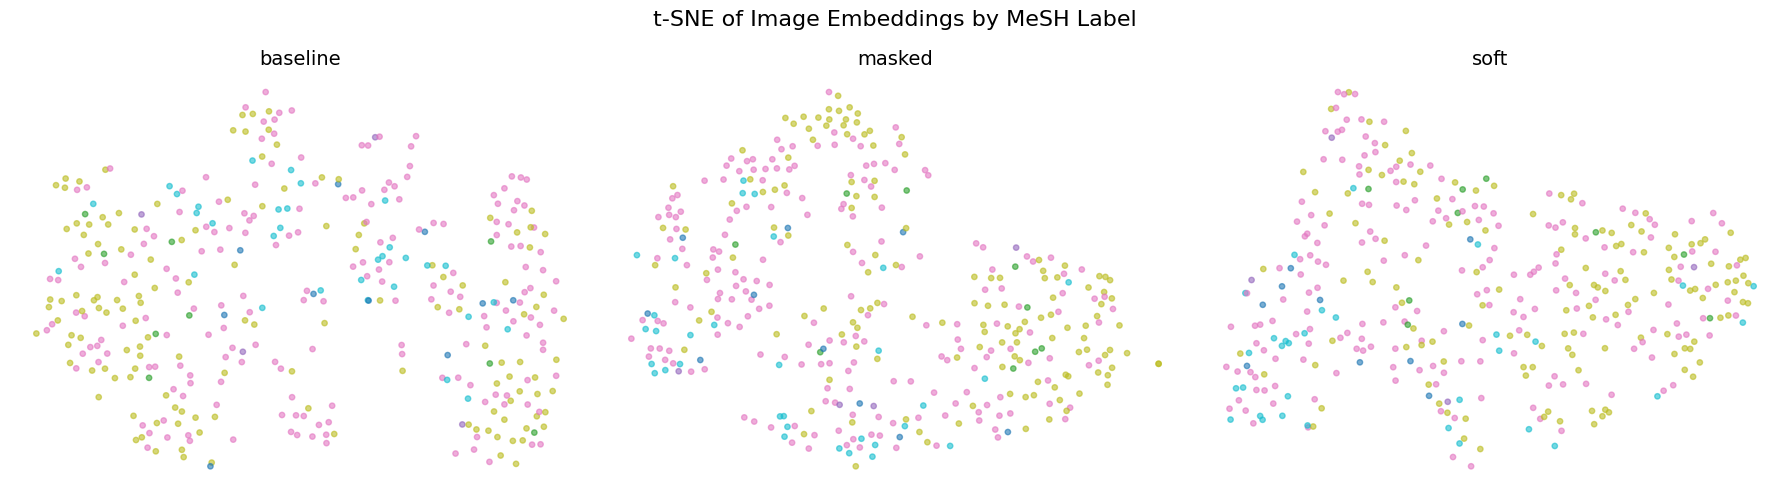

Saved to results/tsne_comparison.png


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import sys
sys.path.append("src")

from dataset import load_splits, IUXrayDataset
from model import MedCLIP
from torch.utils.data import DataLoader

DEVICE = "mps"

def get_embeddings_for_tsne(checkpoint, df):
    ds = IUXrayDataset(df)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
    model = MedCLIP().to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()
    all_img, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            pv = batch["pixel_values"].to(DEVICE)
            ids = batch["input_ids"].to(DEVICE)
            am = batch["attention_mask"].to(DEVICE)
            img_emb, _ = model.get_embeddings(pv, ids, am)
            all_img.append(img_emb.cpu())
    return torch.cat(all_img).numpy()

_, _, test_df = load_splits()

#get top 5 MeSH labels for coloring
top_labels = ["normal", "Cardiomegaly/mild", "Lung/hypoinflation", "Granulomatous Disease", "Pleural Effusion/bilateral"]

def get_color_labels(df):
    colors = []
    for mesh in df["mesh_labels"].fillna(""):
        matched = "other"
        for l in top_labels:
            if l in mesh:
                matched = l
                break
        colors.append(matched)
    return colors

color_labels = get_color_labels(test_df)
label_to_int = {l: i for i, l in enumerate(set(color_labels))}
color_ints = [label_to_int[l] for l in color_labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["baseline", "masked", "soft"]):
    embs = get_embeddings_for_tsne(f"results/{name}_best.pt", test_df)
    reduced = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(embs)
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], c=color_ints, cmap="tab10", alpha=0.6, s=15)
    ax.set_title(f"{name}", fontsize=14)
    ax.axis("off")

plt.suptitle("t-SNE of Image Embeddings by MeSH Label", fontsize=16)
plt.tight_layout()
plt.savefig("results/tsne_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/tsne_comparison.png")